# Price

### Packages

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


### Google Drive

In [2]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Reading data from Google Drive

In [3]:
# path = "/content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed_mega/eurusd_master_returns_201901_202604_avg100_stride100.parquet"
# df = pd.read_parquet(path)

### Reading ask and bid data from local and using mid-price

In [4]:
import re
from pathlib import Path

import pandas as pd

SYMBOL = "eurusd"
PROCESSED = Path("/content/drive/MyDrive/GITHUB-COLAB/stk-mat2011/data/processed")
START_YYYYMM = "202601"


def discover_bid_months() -> list[str]:
    pat = re.compile(rf"^{re.escape(SYMBOL)}_dukascopy_bid_(\d{{6}})\.parquet$", re.I)
    months: set[str] = set()
    for fp in PROCESSED.glob(f"{SYMBOL}_dukascopy_bid_*.parquet"):
        m = pat.match(fp.name)
        if m:
            months.add(m.group(1))
    return sorted(months)


def load_bid_stream(months: list[str]) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for ym in months:
        fp = PROCESSED / f"{SYMBOL}_dukascopy_bid_{ym}.parquet"
        if not fp.is_file():
            continue
        d = pd.read_parquet(fp, columns=["datetime", "price"])
        d["datetime"] = pd.to_datetime(d["datetime"], utc=True)
        d = d.rename(columns={"price": "bid"})
        frames.append(d)

    if not frames:
        raise FileNotFoundError(
            f"No bid parquet files under {PROCESSED.resolve()} "
            f"(pattern {SYMBOL}_dukascopy_bid_YYYYMM.parquet)."
        )

    out = pd.concat(frames, ignore_index=True)
    out = out.sort_values("datetime").drop_duplicates("datetime", keep="last")
    return out.reset_index(drop=True)


months = discover_bid_months()
months = [m for m in months if m >= START_YYYYMM]

df = load_bid_stream(months)
df = df.rename(columns={"bid": "price"})  # optional: keep column name "bid" instead

# optional: calendar month tag for filtering / plots
df["yyyymm"] = df["datetime"].dt.strftime("%Y%m")

### Trying to get familiar with how the prices look

In [5]:
df.info(memory_usage="deep")
print(f"shape (rows, cols): {df.shape}")

display(df.head())
display(df.tail())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5668209 entries, 0 to 5668208
Data columns (total 3 columns):
 #   Column    Dtype              
---  ------    -----              
 0   datetime  datetime64[ns, UTC]
 1   price     float64            
 2   yyyymm    object             
dtypes: datetime64[ns, UTC](1), float64(1), object(1)
memory usage: 383.8 MB
shape (rows, cols): (5668209, 3)


,datetime,price,yyyymm
0,2026-01-01 22:04:01.135000+00:00,1.17387,202601
1,2026-01-01 22:04:37.436000+00:00,1.17414,202601
2,2026-01-01 22:05:00.073000+00:00,1.17414,202601
3,2026-01-01 22:05:00.283000+00:00,1.17449,202601
4,2026-01-01 22:05:01.142000+00:00,1.17449,202601


,datetime,price,yyyymm
5668204,2026-04-02 15:07:18.078000+00:00,1.15546,202604
5668205,2026-04-02 15:07:18.587000+00:00,1.15547,202604
5668206,2026-04-02 15:07:18.692000+00:00,1.15546,202604
5668207,2026-04-02 15:07:18.899000+00:00,1.15545,202604
5668208,2026-04-02 15:07:19.053000+00:00,1.15545,202604


datetime    datetime64[ns, UTC]
price                   float64
yyyymm                   object
dtype: object


### Parse time

In [6]:
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")

tmin, tmax = df["datetime"].min(), df["datetime"].max()
print("time range:", tmin, "->", tmax)
print(df.isna().sum())
print("rows with NaN price:", df["price"].isna().sum())
print("inf price:", np.isinf(df["price"]).sum())

time range: 2026-01-01 22:04:01.135000+00:00 -> 2026-04-02 15:07:19.053000+00:00
datetime    0
price       0
yyyymm      0
dtype: int64
rows with NaN price: 0
inf price: 0


### Duplicates and reordering

In [7]:
df = df.sort_values("datetime").reset_index(drop=True)

print("duplicate datetimes:", df["datetime"].duplicated().sum())
print("strictly increasing by time:", df["datetime"].is_monotonic_increasing)

duplicate datetimes: 0
strictly increasing by time: True


### Gaps between observations

In [8]:
dt = df["datetime"].diff().dropna()

print("Δt (seconds) — describe:\n")
print(dt.dt.total_seconds().describe(percentiles=[0.01, 0.5, 0.99, 0.999]))

worst = dt.nlargest(20)
print(worst)

Δt (seconds) — describe:

count    5.668208e+06
mean     1.382694e+00
std      2.613393e+02
min      5.100000e-02
1%       5.200000e-02
50%      2.070000e-01
99%      1.100300e+01
99.9%    3.042159e+01
max      1.730426e+05
Name: datetime, dtype: float64
2547289   2 days 00:04:02.596000
337914    2 days 00:01:28.967000
2278386   2 days 00:00:51.906000
5260527   2 days 00:00:06.736000
54536     2 days 00:00:06.285000
4097895   2 days 00:00:05.729000
1918932   2 days 00:00:05.553000
603467    2 days 00:00:03.555000
4623516   2 days 00:00:03.333000
2836350   2 days 00:00:02.162000
932183    2 days 00:00:01.581000
1506261   2 days 00:00:01.403000
3480295   1 days 23:00:11.108000
5260597   0 days 00:06:09.219000
2412799   0 days 00:04:59.083000
2308723   0 days 00:04:52.668000
2307550   0 days 00:04:41.848000
4908239   0 days 00:04:19.061000
3351004   0 days 00:04:06.454000
553208    0 days 00:03:59.396000
Name: datetime, dtype: timedelta64[ns]


### Observations per calendar year

In [9]:
df["date"] = df["datetime"].dt.strftime("%Y-%m-%d")

daily_n = df.groupby("date", sort=True).size().rename("n_obs").reset_index()
print(daily_n["n_obs"].describe())
display(daily_n.sort_values("n_obs").head(15))
display(daily_n.sort_values("n_obs").tail(15))

count        79.000000
mean      71749.481013
std       44407.788419
min        1361.000000
25%       51083.500000
50%       65888.000000
75%      101544.000000
max      201410.000000
Name: n_obs, dtype: float64


,date,n_obs
8,2026-01-11,1361
38,2026-02-15,1859
0,2026-01-01,2631
2,2026-01-04,3124
32,2026-02-08,3443
44,2026-02-22,4070
74,2026-03-29,5380
14,2026-01-18,5399
68,2026-03-22,5627
26,2026-02-01,6185


,date,n_obs
53,2026-03-04,112455
77,2026-04-01,112653
24,2026-01-29,112965
23,2026-01-28,116927
27,2026-02-02,116933
76,2026-03-31,120432
58,2026-03-10,126006
55,2026-03-06,127849
54,2026-03-05,132324
25,2026-01-30,140049


### Prices and returns

In [10]:
df = df.sort_values("datetime").reset_index(drop=True)
df["logret"] = np.log(df["price"] / df["price"].shift(1))
df["logret"] = df["logret"].replace([np.inf, -np.inf], np.nan)
print(f"nan logret: {df["logret"].isna().sum()}")

df = df.dropna(subset=["logret"]).reset_index(drop=True)
print(df[["datetime","price","logret"]].describe())

nan logret: 1
              price        logret
count  5.668208e+06  5.668208e+06
mean   1.168309e+00 -2.790318e-09
std    1.436824e-02  1.521881e-05
min    1.141080e+00 -6.286396e-03
25%    1.156790e+00 -8.612486e-06
50%    1.164350e+00  0.000000e+00
75%    1.180370e+00  8.603298e-06
max    1.208220e+00  3.215993e-03


### Price plotting

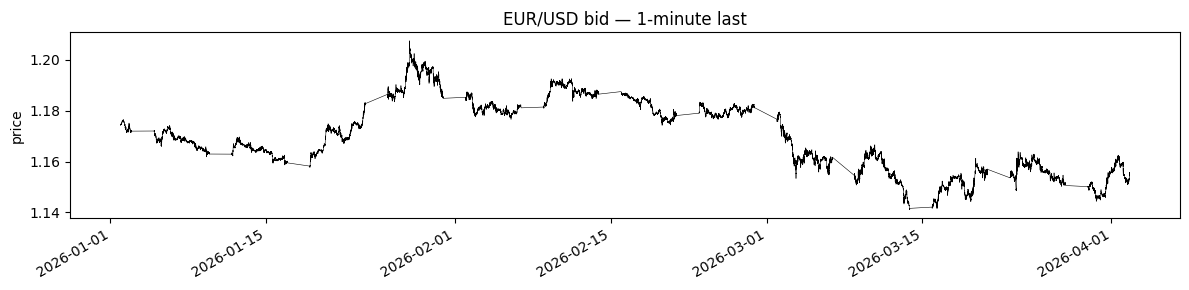

In [11]:
px = df.set_index("datetime")["price"].resample("1min").last().dropna()
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(px.index, px.values, lw=0.4, color="black")
ax.set_title("EUR/USD bid — 1-minute last")
ax.set_ylabel("price")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Histogram

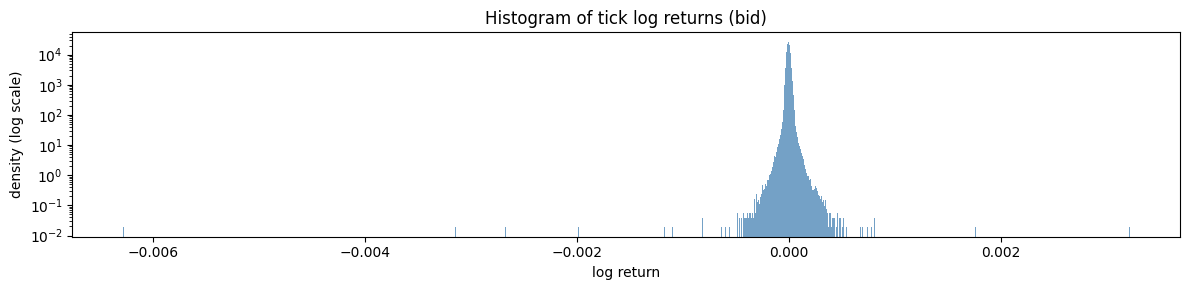

count    5.668208e+06
mean    -2.790318e-09
std      1.521881e-05
min     -6.286396e-03
0.1%    -6.827706e-05
1%      -3.436513e-05
50%      0.000000e+00
99%      3.465061e-05
99.9%    6.936304e-05
max      3.215993e-03
Name: logret, dtype: float64


In [12]:
r = df["logret"]
# Optional: r = r.sample(min(len(r), 500_000), random_state=0)

fig, ax = plt.subplots(figsize=(12, 3))
counts, bin_edges, patches = ax.hist(r, density=True, alpha=0.75, color="steelblue", bins=1000)
ax.set_yscale("log")
ax.set_title("Histogram of tick log returns (bid)")
ax.set_xlabel("log return")
ax.set_ylabel("density (log scale)")
plt.tight_layout()
plt.show()

print(r.describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]))

### QQ-plot

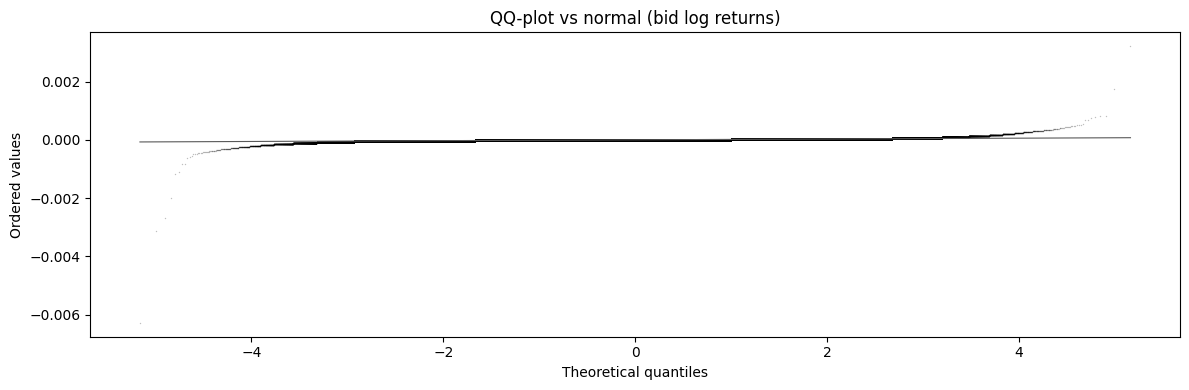

In [13]:
r = df["logret"]
# Optional: r = r.sample(min(len(r), 200_000), random_state=0)

(osm, osr), (slope, intercept, _) = stats.probplot(r, dist="norm", fit=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(osm, osr, s=1, c="k", alpha=0.25, linewidths=0, rasterized=True)

xs = np.array([osm.min(), osm.max()], dtype=float)
ax.plot(xs, slope * xs + intercept, color="0.35", lw=0.8)

ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Ordered values")
ax.set_title("QQ-plot vs normal (bid log returns)")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

### Realized variance and mean

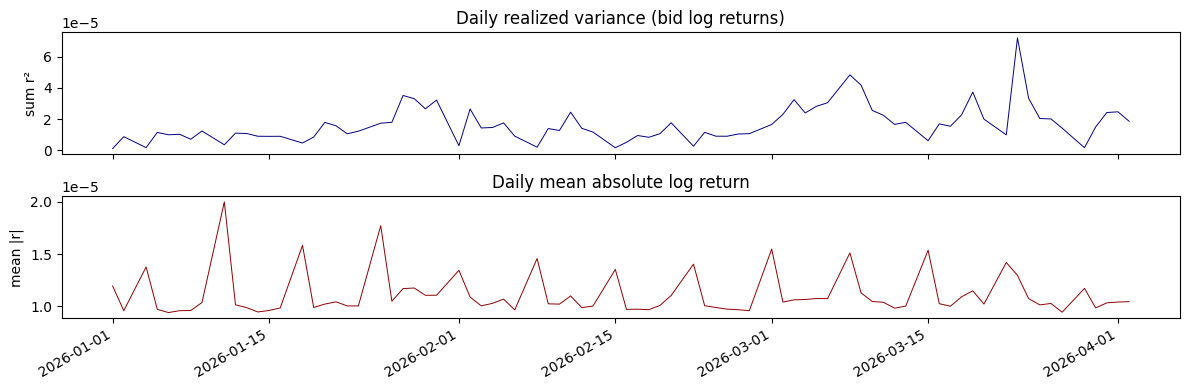

,date,rv,mabs,n
count,79,79.000000,79.000000,79.000000
mean,2026-02-15 17:55:26.582278400,0.000017,0.000011,71749.468354
min,2026-01-01 00:00:00,0.000001,0.000009,1361.000000
25%,2026-01-24 00:00:00,0.000009,0.000010,51083.500000
50%,2026-02-16 00:00:00,0.000014,0.000010,65888.000000
75%,2026-03-10 12:00:00,0.000023,0.000011,101544.000000
max,2026-04-02 00:00:00,0.000072,0.000020,201410.000000
std,NaN,0.000012,0.000002,44407.808373


In [14]:
daily = (
    df.groupby("date", sort=True)["logret"]
    .agg(rv=lambda x: float(np.sum(x**2)), mabs=lambda x: float(np.mean(np.abs(x))), n="count")
    .reset_index()
)
daily["date"] = pd.to_datetime(daily["date"])
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(daily["date"], daily["rv"], lw=0.7, color="navy")
axes[0].set_ylabel("sum r²")
axes[0].set_title("Daily realized variance (bid log returns)")
axes[1].plot(daily["date"], daily["mabs"], lw=0.7, color="darkred")
axes[1].set_ylabel("mean |r|")
axes[1].set_title("Daily mean absolute log return")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
display(daily.describe())

In [15]:
p = df.sort_values("datetime").set_index("datetime")["price"]
p = p.resample("1s").last().dropna()
r_1s = np.log(p / p.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
r_1s.name = "logret_1s"
# ACF/PACF: use a short recent slice so statsmodels stays fast
lookback = pd.Timedelta(days=5)
r_1s = r_1s.loc[r_1s.index.max() - lookback:]
print(r_1s.describe())
print("n:", len(r_1s))

count    1.559920e+05
mean     2.702077e-08
std      2.435037e-05
min     -3.790065e-04
25%     -8.718054e-06
50%      0.000000e+00
75%      8.716534e-06
max      4.392103e-04
Name: logret_1s, dtype: float64
n: 155992


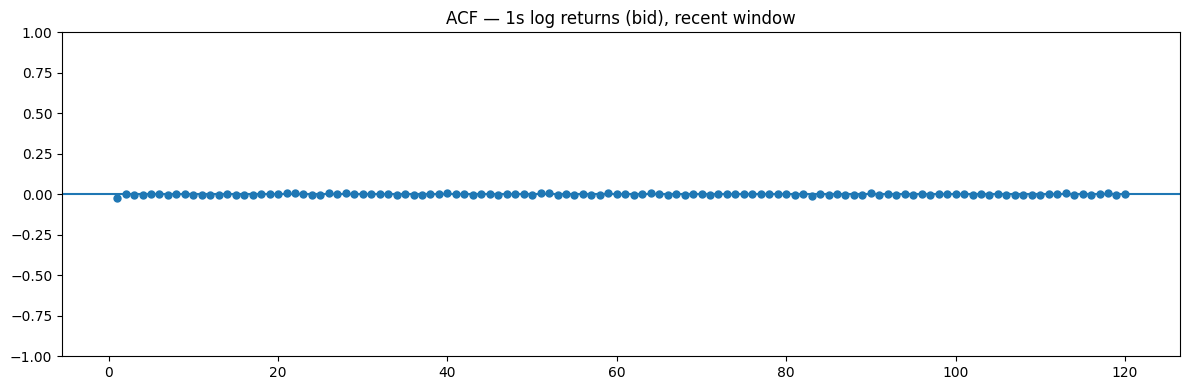

In [16]:
lags = 120
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(
    r_1s,
    lags=lags,
    ax=ax,
    alpha=0.05,
    bartlett_confint=True,
    zero=False,
    fft=True,
)
ax.set_title("ACF — 1s log returns (bid), recent window")
plt.tight_layout()
plt.show()

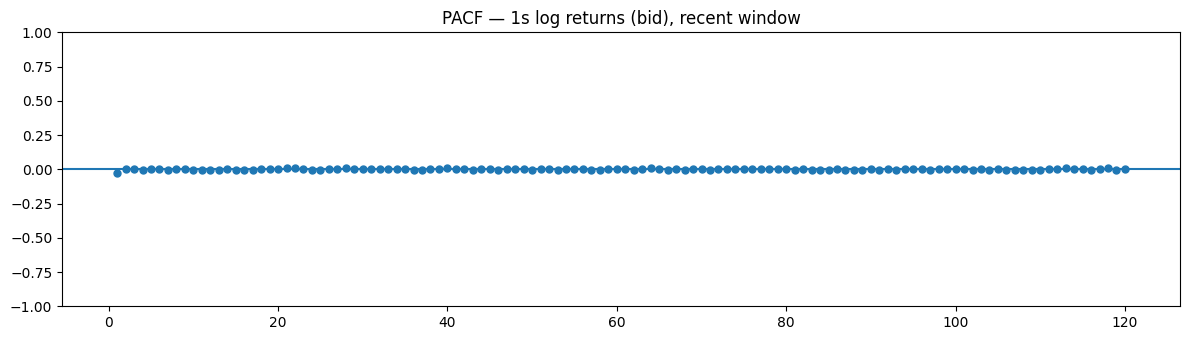

In [17]:
lags = 120
fig, ax = plt.subplots(figsize=(12, 3.5))
plot_pacf(r_1s, lags=lags, ax=ax, alpha=0.05, method="ywm", zero=False)
ax.set_title("PACF — 1s log returns (bid), recent window")
plt.tight_layout()
plt.show()

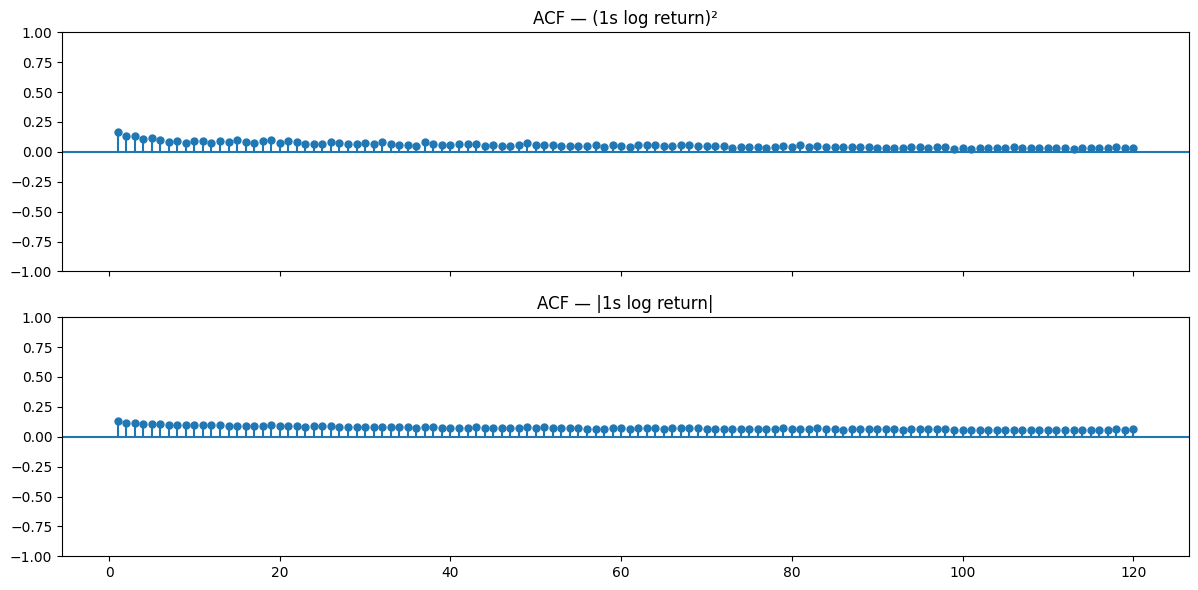

In [18]:
lags = 120
r2 = (r_1s**2).rename("r2")
abr = r_1s.abs().rename("abs_r")
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
plot_acf(r2, lags=lags, ax=axes[0], alpha=0.05, bartlett_confint=True, zero=False, fft=True)
axes[0].set_title("ACF — (1s log return)²")
plot_acf(abr, lags=lags, ax=axes[1], alpha=0.05, bartlett_confint=True, zero=False, fft=True)
axes[1].set_title("ACF — |1s log return|")
plt.tight_layout()
plt.show()

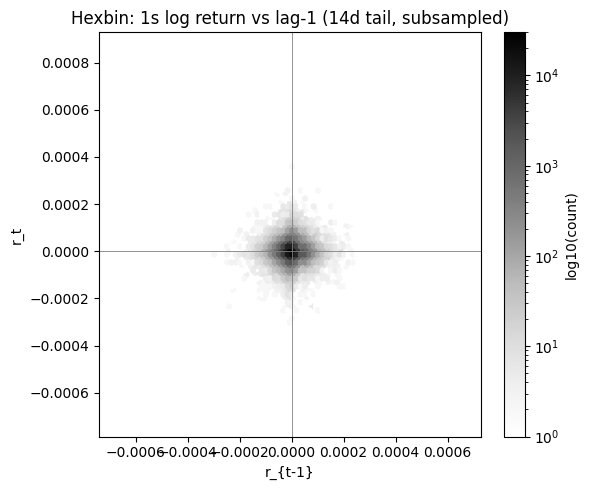

In [19]:
p = df.sort_values("datetime").set_index("datetime")["price"]
p = p.resample("1s").last().dropna()
r = np.log(p / p.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
r_tail = r.loc[r.index.max() - pd.Timedelta(days=14):]
x = r_tail.shift(1)
y = r_tail
m = x.notna() & y.notna()
x, y = x[m], y[m]
n = min(200_000, len(x))
rng = np.random.default_rng(0)
idx = rng.choice(len(x), size=n, replace=False)
fig, ax = plt.subplots(figsize=(6, 5))
hb = ax.hexbin(x.iloc[idx], y.iloc[idx], gridsize=80, bins="log", cmap="Greys", mincnt=1)
ax.axhline(0, color="0.5", lw=0.6)
ax.axvline(0, color="0.5", lw=0.6)
ax.set_xlabel("r_{t-1}")
ax.set_ylabel("r_t")
ax.set_title("Hexbin: 1s log return vs lag-1 (14d tail, subsampled)")
plt.colorbar(hb, ax=ax, label="log10(count)")
plt.tight_layout()
plt.show()

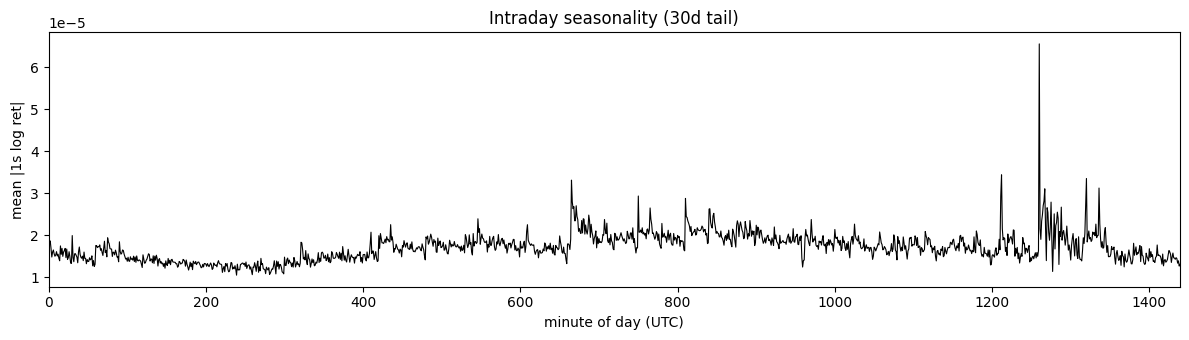

In [20]:
p = df.sort_values("datetime").set_index("datetime")["price"]
p = p.resample("1s").last().dropna()
r = np.log(p / p.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
r_tail = r.loc[r.index.max() - pd.Timedelta(days=30):]
mod = r_tail.index.hour * 60 + r_tail.index.minute
s = pd.Series(np.abs(r_tail.values), index=mod).groupby(level=0).mean()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(s.index, s.values, lw=0.8, color="black")
ax.set_xlabel("minute of day (UTC)")
ax.set_ylabel("mean |1s log ret|")
ax.set_title("Intraday seasonality (30d tail)")
ax.set_xlim(0, 24 * 60 - 1)
plt.tight_layout()
plt.show()

In [21]:
p = df.sort_values("datetime").set_index("datetime")["price"]
p = p.resample("1s").last().dropna()
r = np.log(p / p.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()
r_tail = r.loc[r.index.max() - pd.Timedelta(days=1):]
lb = acorr_ljungbox(r_tail**2, lags=[10, 20, 30], model_df=0, return_df=True)
print(lb)

         lb_stat  lb_pvalue
10   7977.001251        0.0
20  11600.410475        0.0
30  16071.524593        0.0


In [24]:
%pip install -q arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.9 MB/s eta 0:00:00a 0:00:01


In [25]:
# pip install arch
import numpy as np
import pandas as pd
from arch import arch_model

p = df.sort_values("datetime").set_index("datetime")["price"]
p = p.resample("1s").last().dropna()
r = np.log(p / p.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()

r_fit = r.loc[r.index.max() - pd.Timedelta(days=20):].dropna()
y = (r_fit * 100.0).astype(float)  # scale

am = arch_model(y, mean="Constant", vol="GARCH", p=1, q=1, rescale=False)
res = am.fit(disp="off")
print(res.summary())

/tmp/ipykernel_28099/3538080697.py:14: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp="off")


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  price   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:            2.72336e+06
Distribution:                  Normal   AIC:                      -5.44670e+06
Method:            Maximum Likelihood   BIC:                      -5.44666e+06
                                        No. Observations:               591040
Date:                Sun, Apr 12 2026   Df Residuals:                   591039
Time:                        19:29:31   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.4855e-06  3.240e-06      0.458      0.647 

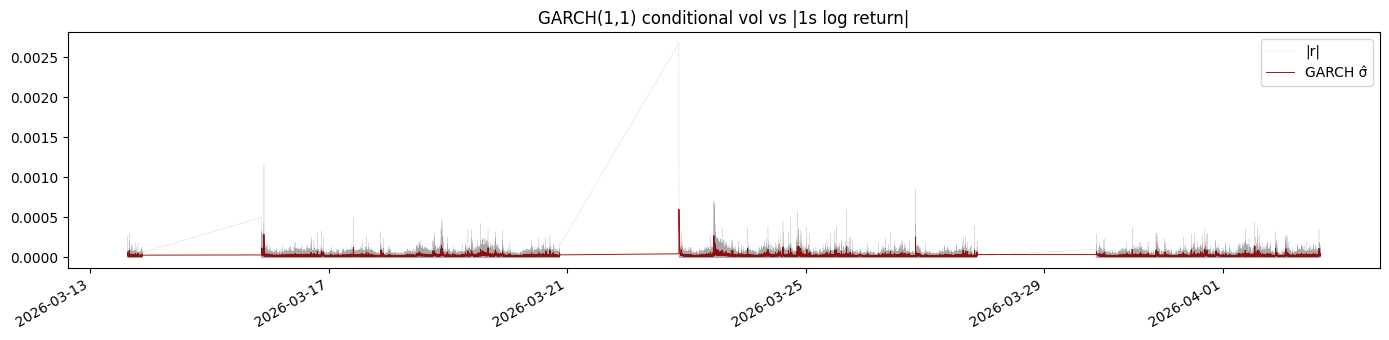

In [26]:
import matplotlib.pyplot as plt

scale = 100.0
cond_vol = res.conditional_volatility / scale
abs_r = np.abs(r_fit)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(r_fit.index, abs_r.values, lw=0.15, color="black", alpha=0.35, label="|r|")
ax.plot(r_fit.index, cond_vol.values, lw=0.7, color="darkred", alpha=0.9, label="GARCH σ̂")
ax.set_title("GARCH(1,1) conditional vol vs |1s log return|")
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

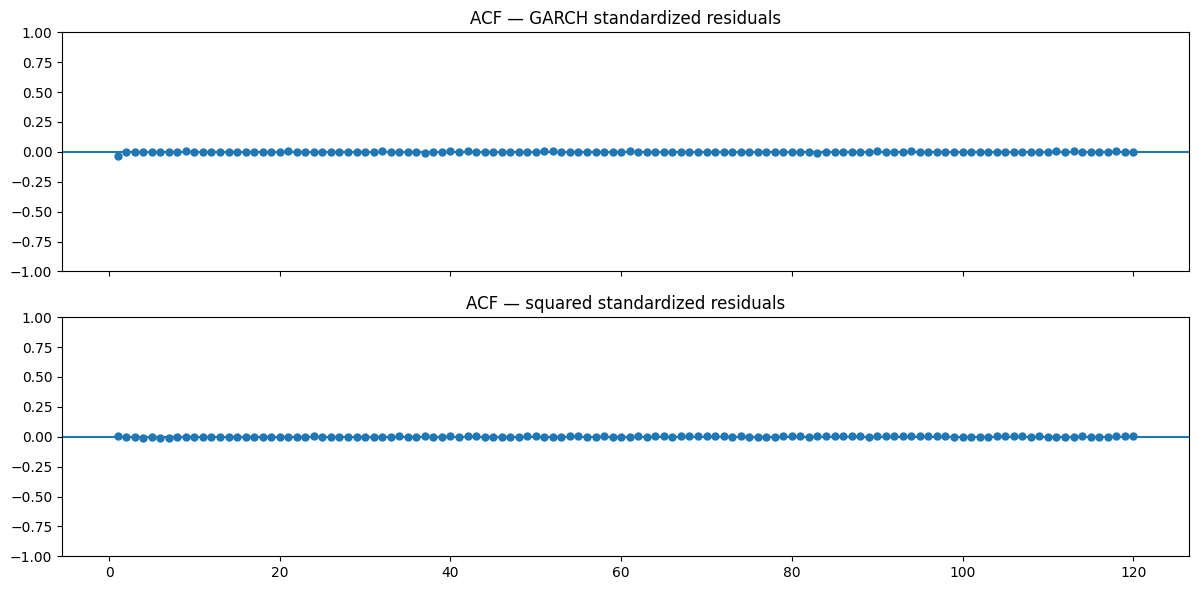

In [27]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

z = pd.Series(res.std_resid, index=r_fit.index).dropna()
z = z.loc[z.index.max() - pd.Timedelta(days=5):]  # keep ACF fast

lags = 120
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
plot_acf(z, lags=lags, ax=axes[0], alpha=0.05, bartlett_confint=True, zero=False, fft=True)
axes[0].set_title("ACF — GARCH standardized residuals")
plot_acf(z**2, lags=lags, ax=axes[1], alpha=0.05, bartlett_confint=True, zero=False, fft=True)
axes[1].set_title("ACF — squared standardized residuals")
plt.tight_layout()
plt.show()

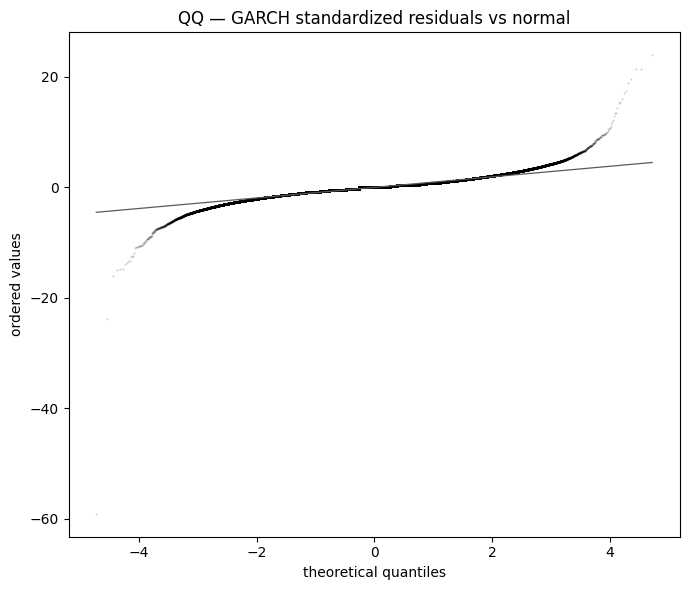

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

z = np.asarray(res.std_resid)
z = z[np.isfinite(z)]
# Optional: z = np.random.default_rng(0).choice(z, size=min(len(z), 100_000), replace=False)

(osm, osr), (slope, intercept, _) = stats.probplot(z, dist="norm", fit=True)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(osm, osr, s=2, c="k", alpha=0.2, linewidths=0, rasterized=True)
xs = np.array([osm.min(), osm.max()], dtype=float)
ax.plot(xs, slope * xs + intercept, color="0.35", lw=0.9)
ax.set_title("QQ — GARCH standardized residuals vs normal")
ax.set_xlabel("theoretical quantiles")
ax.set_ylabel("ordered values")
plt.tight_layout()
plt.show()

In [30]:
%pip install -q hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.6 MB/s eta 0:00:00


In [31]:
# pip install hmmlearn
import numpy as np
import pandas as pd
from hmmlearn import hmm

p = df.sort_values("datetime").set_index("datetime")["price"]
p = p.resample("1s").last().dropna()
r = np.log(p / p.shift(1)).replace([np.inf, -np.inf], np.nan).dropna()

r_tail = r.loc[r.index.max() - pd.Timedelta(days=14):].dropna()
X = r_tail.to_numpy().reshape(-1, 1)

n_use = min(400_000, len(X))
X_fit = X[:n_use]

model = hmm.GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=200,
    random_state=0,
    init_params="stmc",
)
model.fit(X_fit)
states = model.predict(X_fit)

print("startprob:\n", model.startprob_)
print("transmat:\n", model.transmat_)
print("means:\n", model.means_.ravel())

startprob:
 [1.00000000e+00 7.48626856e-68 1.45427514e-13]
transmat:
 [[9.99997483e-01 3.13842344e-34 2.51721100e-06]
 [9.98939016e-01 2.23170774e-55 1.06098437e-03]
 [1.00000000e+00 1.44422522e-37 1.19943500e-13]]
means:
 [ 1.64965460e-08 -2.65141470e-03 -2.65195281e-03]


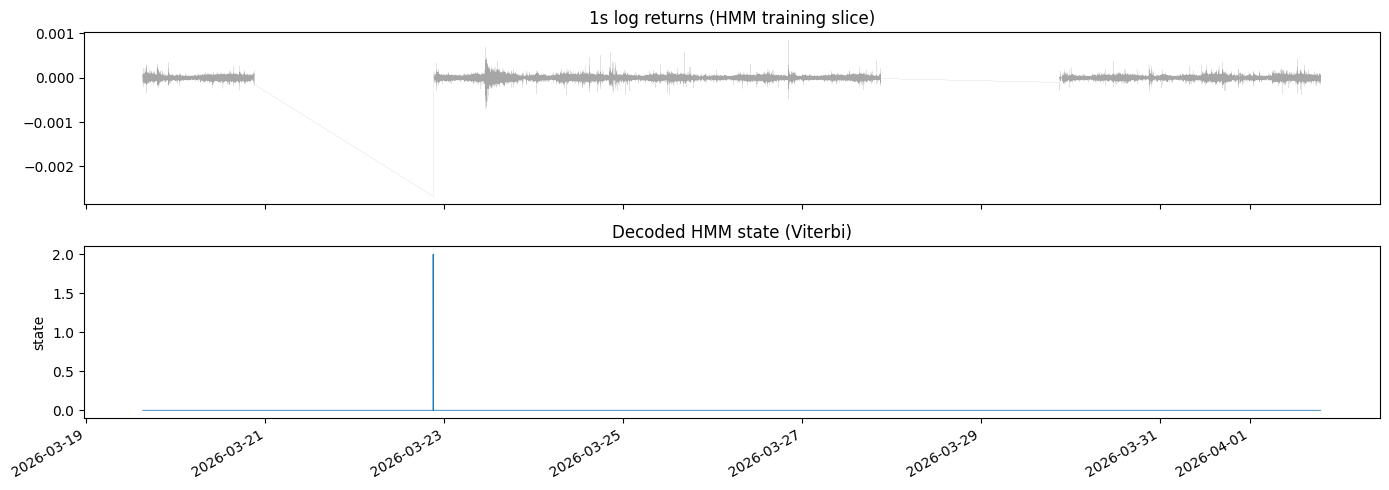

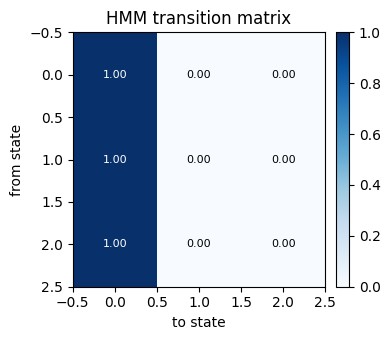

In [32]:
import matplotlib.pyplot as plt

idx = r_tail.index[:n_use]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(idx, X_fit.ravel(), lw=0.12, color="black", alpha=0.35)
axes[0].set_title("1s log returns (HMM training slice)")
axes[1].step(idx, states, where="post", lw=0.6)
axes[1].set_ylabel("state")
axes[1].set_title("Decoded HMM state (Viterbi)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(model.transmat_, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("to state")
ax.set_ylabel("from state")
ax.set_title("HMM transition matrix")
for (i, j), v in np.ndenumerate(model.transmat_):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()